# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ali-Haider987/alihaider-flyrank-ml/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

import pandas as pd, numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)
print(df.shape[0], "pages |  declining rate:", round(df["is_declining_label"].mean(), 3))


30000 pages |  declining rate: 0.542


## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

       impressions_90d  word_count       ctr
count         30000.00    22301.00  30000.00
mean           5200.37     3107.76      0.51
std           16838.02     1452.38      3.28
min               1.00        8.00      0.00
25%              81.00     2413.00      0.00
50%             731.00     2877.00      0.07
75%            3615.25     3666.00      0.29
max          517715.00     9546.00    100.00


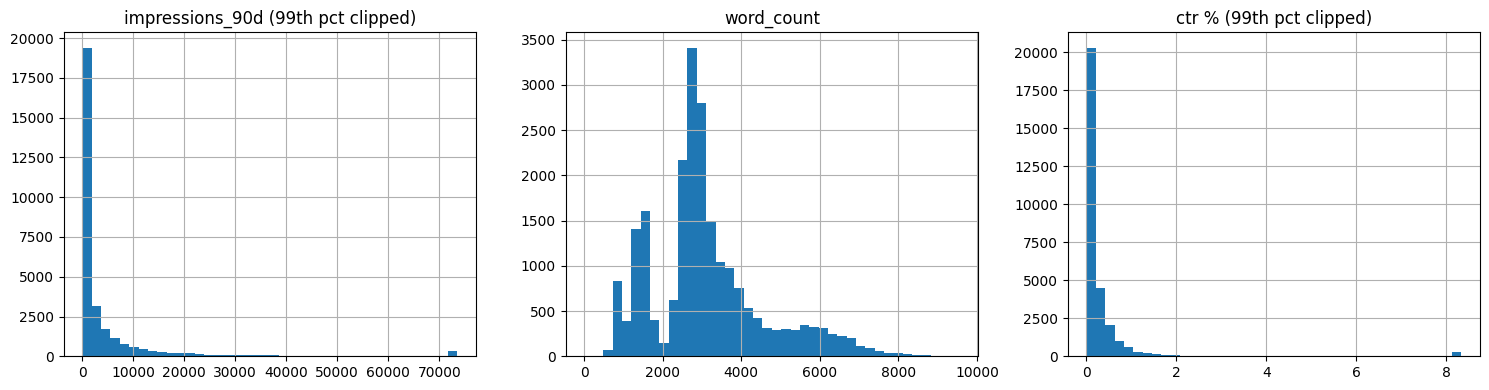

In [3]:
print(df[["impressions_90d", "word_count", "ctr"]].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df["impressions_90d"].clip(upper=df["impressions_90d"].quantile(0.99)).hist(bins=40, ax=axes[0])
axes[0].set_title("impressions_90d (99th pct clipped)")
df["word_count"].dropna().hist(bins=40, ax=axes[1])
axes[1].set_title("word_count")
df["ctr"].clip(upper=df["ctr"].quantile(0.99)).hist(bins=40, ax=axes[2])
axes[2].set_title("ctr % (99th pct clipped)")
plt.tight_layout()
plt.show()

Heavy tails, as expected: impressions_90d ranges 1 to 517,715 with a median of only 731 -- a
few giant pages, a long tail of small ones. word_count is much more evenly spread (median
~2,877, missing for 7,699 rows -- systematically, per content_type, not at random). ctr is also
right-skewed with a long tail of near-zero values. Because of this, every bucket table below uses
the repo's own pre-built tiers (median-safe, human-readable) instead of raw Pearson correlation on
the untransformed numbers, which a few giant pages would otherwise dominate.


## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

All three are signals my `stale x visible` rule (from `w04_baseline_score.ipynb`) leans on or could lean on.

In [5]:
# --- Test 1: staleness -> decline (behind FlyRank's refresh flags) ---
order1 = ["0-30", "31-90", "91-180", "181+"]
df["freshness_tier"] = pd.Categorical(df["freshness_tier"], categories=order1, ordered=True)
print("Claim: \"the longer since a page was updated, the more likely it is declining.\"")
print(df.groupby("freshness_tier", observed=True)["is_declining_label"].agg(mean="mean", n="count").round(3))


Claim: "the longer since a page was updated, the more likely it is declining."
                 mean      n
freshness_tier              
0-30            0.511  20480
31-90           0.589    175
91-180          0.611   9171
181+            0.471    174



### **VERDICT**:
 MIXED. Holds in the two big tiers (0-30: 51.1%, n=20,480 vs. 91-180: 61.1%, n=9,171 --
a real ~10pp gap in the assumed direction) but breaks in the two thin tiers (31-90 n=175,
181+ n=174), which sit near or below the fresh tier despite being "staler." Both thin tiers clear
the ~50-row floor but are 20-50x smaller than the big tiers, so I read that break as thin-sample
noise, not a real reversal -- still, it stops me from calling this a clean CONFIRMED.

In [6]:
# --- Test 2: visibility -> decline (the other half of my rule) ---
order2 = ["low", "moderate", "good", "excellent"]
df["impression_tier"] = pd.Categorical(df["impression_tier"], categories=order2, ordered=True)
print("Claim: \"more visible (higher-traffic) pages are more likely to be declining.\"")
print(df.groupby("impression_tier", observed=True)["is_declining_label"].agg(mean="mean", n="count").round(3))


Claim: "more visible (higher-traffic) pages are more likely to be declining."
                  mean      n
impression_tier              
low              0.454  11248
moderate         0.615  10469
good             0.586   7205
excellent        0.462   1078


### **VERDICT**:
MIXED. This is a U-shape, not a trend: low (45.4%, n=11,248) and excellent (46.2%,
n=1,078) traffic pages BOTH decline less than the middle tiers, moderate (61.5%, n=10,469) and
good (58.6%, n=7,205). Visibility does not predict decline on its own -- which tells me it belongs
in my rule as a materiality FILTER ("don't bother flagging pages nobody sees"), not as a
decline-driving reason code.

In [7]:
# --- Test 3: word count -> decline (a common SEO belief, not currently in my rule) ---
order3 = ["<1000", "1000-2000", "2000-3500", "3500+"]
df["word_count_tier"] = pd.Categorical(df["word_count_tier"], categories=order3, ordered=True)
print("Claim: \"longer content is less likely to be declining.\"")
print(df.groupby("word_count_tier", observed=True)["is_declining_label"].agg(mean="mean", n="count").round(3))

confound = df[df["word_count_tier"] == "<1000"]["content_type"].value_counts()
print("\ncontent_type mix inside the <1000-word tier (checking for a confound):")
print(confound)


Claim: "longer content is less likely to be declining."
                  mean      n
word_count_tier              
<1000            0.207    973
1000-2000        0.556   3780
2000-3500        0.588  11263
3500+            0.597   6285

content_type mix inside the <1000-word tier (checking for a confound):
content_type
feedly article     854
keyword article    119
Name: count, dtype: int64


### **VERDICT**:
 OPPOSITE. Decline rate actually RISES with length -- <1000 words: 20.7% (n=973),
then 55.6% / 58.8% / 59.7% for the three longer tiers (n=3,780 / 11,263 / 6,285). "Write more"
is not the lever this data supports.
But before trusting that at face value: 973 of the 973 <1000-word rows are 854 "feedly article" +
119 "keyword article" -- feedly articles are a distinct, short-format content_type, not just short
keyword articles that happen to be brief. So this table is partly measuring content_type, not word
count in isolation. Directionally OPPOSITE of the popular belief, but the effect is confounded and
should not be read as "shortening pages helps."

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

This is the CTR-fix logic: the assumption behind it is that click-through rate collapses as average position gets worse, so a page ranking well but still under-clicking is the CTR-fix flag's real target.

In [8]:
order4 = ["top_3", "page_1", "striking", "page_3_5", "deep"]
df["position_tier"] = pd.Categorical(df["position_tier"], categories=order4, ordered=True)
visible_enough = df[df["impressions_90d"] >= 100]  # volume floor -- see flyrank-data skill note

simple_mean = visible_enough.groupby("position_tier", observed=True)["ctr"].agg(mean="mean", n="count").round(3)
print("Simple mean CTR by position tier (impressions_90d >= 100):")
print(simple_mean)

# Weighted (total clicks / total impressions) -- averaging per-row rates is not the true rate.
weighted = visible_enough.groupby("position_tier", observed=True).apply(
    lambda g: g["clicks_90d"].sum() / g["impressions_90d"].sum()
).round(4)
print("\nWeighted CTR by position tier (total clicks / total impressions):")
print(weighted)


Simple mean CTR by position tier (impressions_90d >= 100):
                mean     n
position_tier             
top_3          0.334   533
page_1         0.355  8633
striking       0.256  5903
page_3_5       0.142  6058
deep           0.055   879

Weighted CTR by position tier (total clicks / total impressions):
position_tier
top_3       0.0049
page_1      0.0035
striking    0.0035
page_3_5    0.0015
deep        0.0004
dtype: float64


/tmp/ipykernel_495/1939388825.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted = visible_enough.groupby("position_tier", observed=True).apply(



### **VERDICT:**
CONFIRMED. The weighted CTR falls monotonically as position gets worse: 0.49% (top_3)
-> 0.35% (page_1) -> 0.35% (striking) -> 0.15% (page_3_5) -> 0.04% (deep). The simple per-row mean
is noisier at the very top (top_3 0.334 vs. page_1 0.355) because top_3 has only 533 rows and a
few small-volume pages skew the row-average; the impression-weighted number is the honest read and
it clearly supports the CTR-fix flag's core assumption -- position really does drive the CTR cliff.


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

**For a content team:** trust staleness as a real, directional decline signal for the bulk of the portfolio, but don't chase it into the thin tail of very-old or very-recently-touched pages where the sample is too small to say anything. Don't use raw traffic volume as a decline predictor by itself — use it only to filter out pages too small to matter, since both tiny and huge pages actually decline *less* than the middle. And don't tell writers to simply add words: the longer-declines-more pattern here is a content-type artifact (short pages are disproportionately a different format), not evidence that length helps. The one clean, actionable signal in this audit is the CTR-vs-position cliff — a page holding a good position with a low CTR is a real, well-supported candidate for the CTR-fix flag, independent of staleness.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.